In [1]:
## load dataset 
import pandas as pd

df = pd.read_csv("GoldUSD.csv")

# convert
df["Date"] = pd.to_datetime(df["Date"])

# target 
TARGET_COL = "Close"

# data
data = df[[TARGET_COL]].values

C:\Users\User\AppData\Local\Temp\ipykernel_14160\52110990.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


In [2]:
## EDA
print(f"Cek 5 data teratas \n {df.head()} \n")

print(f"Cek tipe data \n {df.dtypes} \n")

print(f"Cek missing values \n {df.isnull().sum()}")

Cek 5 data teratas 
         Date        Open        High         Low       Close  Volume
0 2000-08-30  273.899994  273.899994  273.899994  273.899994       0
1 2000-08-31  274.799988  278.299988  274.799988  278.299988       0
2 2000-01-09  277.000000  277.000000  277.000000  277.000000       0
3 2000-05-09  275.799988  275.799988  275.799988  275.799988       2
4 2000-06-09  274.200012  274.200012  274.200012  274.200012       0 

Cek tipe data 
 Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
dtype: object 

Cek missing values 
 Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


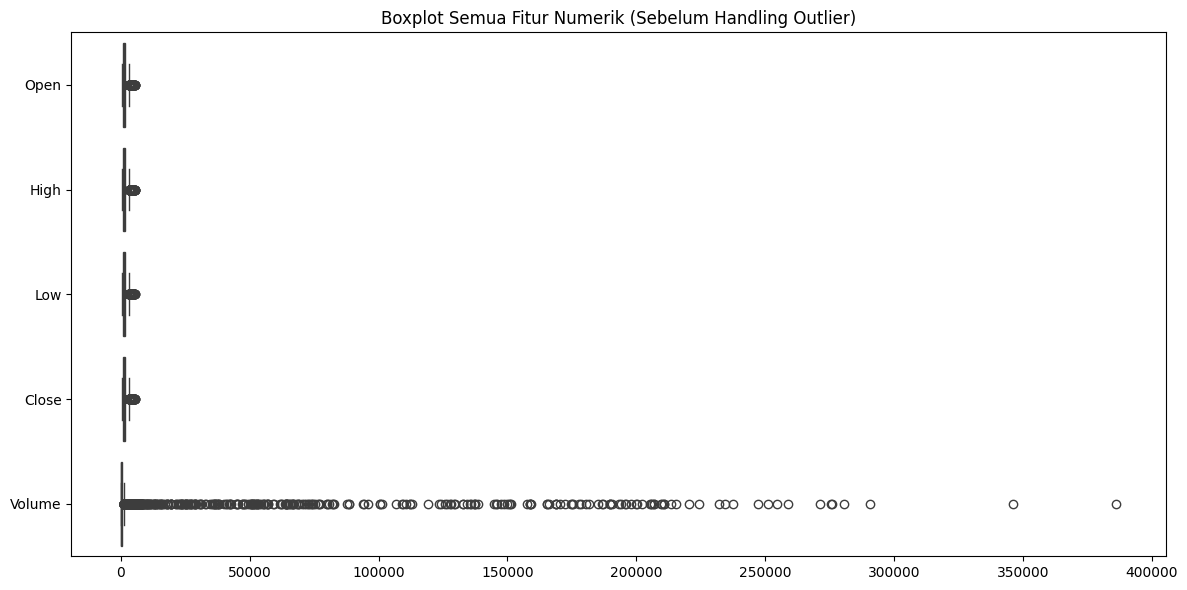

Jumlah outlier per kolom sebelum handling:
Open: 54
High: 55
Low: 53
Close: 53
Volume: 661


In [3]:
## Cek outlier

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

# --- Pilih kolom numerik ---
num_cols = df.select_dtypes(include="number").columns

# --- 0️⃣ Convert kolom ke numeric (handle string / unknown) ---
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # invalid -> NaN

# Optional: isi NaN dengan median supaya bisa cek outlier
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# 1️⃣ Visualisasi boxplot sebelum handling
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols], orient='h')
plt.title("Boxplot Semua Fitur Numerik (Sebelum Handling Outlier)")
plt.tight_layout()
plt.show()

# 2️⃣ Hitung jumlah outlier per kolom pakai IQR
outlier_summary = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 2.5 * IQR
    upper = Q3 + 2.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = outliers

print("Jumlah outlier per kolom sebelum handling:")
for k, v in outlier_summary.items():
    print(f"{k}: {v}")


Jumlah outlier setelah handling:
Open: 0
High: 0
Low: 0
Close: 0
Volume: 0


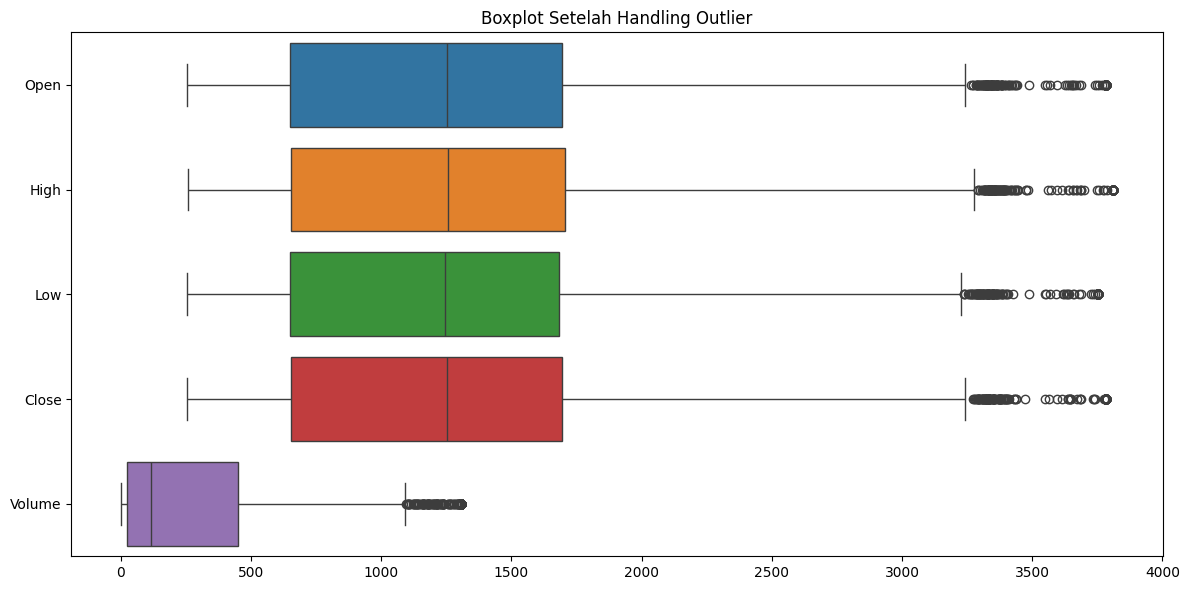

In [4]:
## Handle outlier
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns

strategy = 'cap'  # pilihan: 'remove', 'cap', 'robust'

df_handled = df.copy()
if strategy == 'robust':
    # Robust scaling (tidak menghapus outlier, hanya menstabilkan distribusi)
    scaler = RobustScaler()
    df_handled[num_cols] = scaler.fit_transform(df_handled[num_cols])

else:
    if strategy == 'remove':
        # Buat mask global biar tidak kepotong berkali-kali
        mask = np.ones(len(df_handled), dtype=bool)

    for col in num_cols:
        Q1 = df_handled[col].quantile(0.25)
        Q3 = df_handled[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 2.0 * IQR
        upper = Q3 + 2.0 * IQR

        if strategy == 'remove':
            mask &= (df_handled[col] >= lower) & (df_handled[col] <= upper)

        elif strategy == 'cap':
            df_handled[col] = df_handled[col].clip(lower, upper)

    if strategy == 'remove':
        df_handled = df_handled[mask]
        
outlier_summary_after = {}
for col in num_cols:
    Q1 = df_handled[col].quantile(0.25)
    Q3 = df_handled[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 2.0 * IQR
    upper = Q3 + 2.0 * IQR

    outliers = ((df_handled[col] < lower) | (df_handled[col] > upper)).sum()
    outlier_summary_after[col] = outliers

print("\nJumlah outlier setelah handling:")
for k, v in outlier_summary_after.items():
    print(f"{k}: {v}")

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_handled[num_cols], orient='h')
plt.title("Boxplot Setelah Handling Outlier")
plt.tight_layout()
plt.show()

In [5]:
## Train test split
TRAIN_RATIO = 0.8
train_size = int(len(data) * TRAIN_RATIO)

# bagi data
train_data = data[:train_size]
test_data= data[train_size:]

In [6]:
# scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [7]:
## sliding window
WINDOW_SIZE = 30

def create_window(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i])
    return np.array(X), np.array(y)


X_train, y_train = create_window(train_scaled, WINDOW_SIZE)
X_test,  y_test  = create_window(test_scaled, WINDOW_SIZE)

In [8]:
# build model gru
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# definisi model
model_gru = Sequential([
    LSTM(64, input_shape=(WINDOW_SIZE,1)),
    Dropout(0.3),
    Dense(1)
])

# compile model
model_gru.compile(
    optimizer="adam",
    loss="mse"
)

model_gru.summary()




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 64)                16896     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense (Dense)               (None, 1)                 65        
                                                                 
Total params: 16961 (66.25 KB)
Trainable params: 16961 (66.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [9]:
# training + validation
history = model_gru.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=25,
    batch_size=32,
    verbose=1
)

Epoch 1/25

160/160 [==============================] - 3s 9ms/step - loss: 0.0405 - val_loss: 2.0540
Epoch 2/25
160/160 [==============================] - 1s 7ms/step - loss: 0.0119 - val_loss: 1.6377
Epoch 3/25
160/160 [==============================] - 1s 7ms/step - loss: 0.0108 - val_loss: 1.3630
Epoch 4/25
160/160 [==============================] - 1s 7ms/step - loss: 0.0105 - val_loss: 1.0781
Epoch 5/25
160/160 [==============================] - 1s 7ms/step - loss: 0.0095 - val_loss: 0.8193
Epoch 6/25
160/160 [==============================] - 1s 6ms/step - loss: 0.0094 - val_loss: 1.0049
Epoch 7/25
160/160 [==============================] - 1s 7ms/step - loss: 0.0097 - val_loss: 0.6840
Epoch 8/25
160/160 [==============================] - 1s 7ms/step - loss: 0.0087 - val_loss: 0.5489
Epoch 9/25
160/160 [==============================] - 1s 7ms/step - loss: 0.0098 - val_loss: 0.6113
Epoch 10/25
160/160 [==============================] - 1s 7ms/step - loss: 0.0090 - val_loss: 0.647

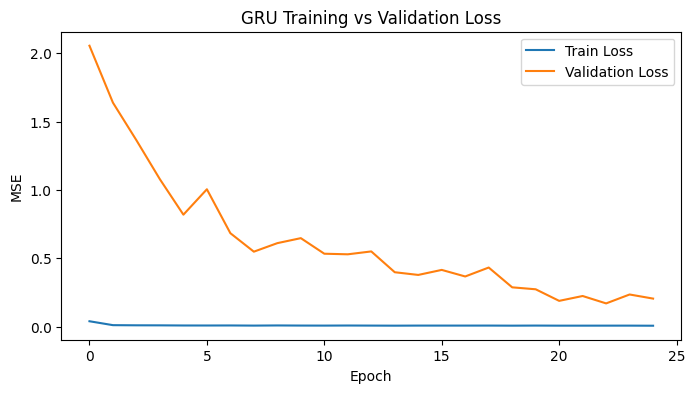

In [10]:
# ploting
plt.figure(figsize=(8,4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("GRU Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

In [14]:
FUTURE_DAYS =30

last_window = data[-WINDOW_SIZE:]
last_window_scaled = scaler.transform(last_window)
current_window = last_window_scaled.reshape(1, WINDOW_SIZE,1)

future_predictions = [] 
for _ in range(FUTURE_DAYS):
    next_pred = model_gru.predict(current_window, verbose=0)
    future_predictions.append(next_pred[0,0])

    current_window = np.append(
        current_window[:,1:, :],
        [[[next_pred[0,0]]]],
        axis=1
    )

future_predictions = np.array(future_predictions).reshape(-1,1)
future_predictions = scaler.inverse_transform(future_predictions)

In [15]:
last_date = df["Date"].iloc[-1]

future_dates = pd.date_range(
    start=last_date,
    periods=FUTURE_DAYS +1,
    freq="D"
)[1:]

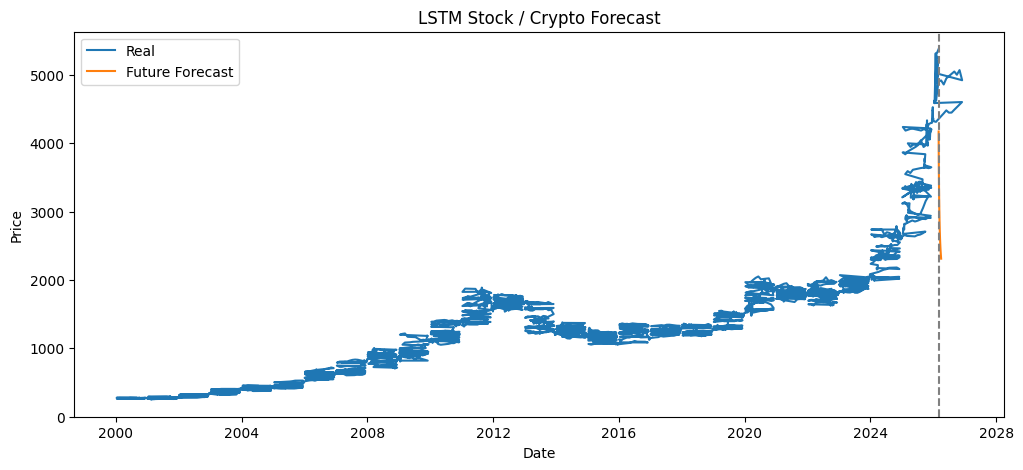

In [16]:
plt.figure(figsize=(12,5))

plt.plot(df["Date"], df[TARGET_COL], label="Real")
plt.plot(future_dates, future_predictions, label="Future Forecast")

plt.axvline(df["Date"].iloc[-1], color="gray", linestyle="--")

plt.legend()
plt.title("LSTM Stock / Crypto Forecast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()